# 🏋️ Model Fitness — Customer Churn & Retention Analysis

## Project Overview

Customer retention is one of the most important challenges for subscription-based businesses.

In this project, I analyse customer behaviour at **Model Fitness**, a fictional gym chain, to understand which factors are associated with churn, predict which customers are at higher risk of leaving, and identify customer segments with different retention patterns.

The project combines:

- exploratory data analysis;
- churn prediction;
- individual risk scoring;
- feature importance;
- customer segmentation;
- clustering;
- business-focused retention recommendations.

The goal is not only to build a predictive model, but to turn the analysis into actions that could help a business improve customer retention.


In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.max_columns', None)


## 1. Data Loading and Initial Review

I begin by loading the dataset and reviewing its structure, dimensions, missing values, and duplicate rows.


In [2]:
# Load the dataset
# The helper makes the notebook easier to reuse outside the course environment.

from pathlib import Path

possible_paths = [
    Path('/datasets/gym_churn_us.csv'),
    Path.cwd() / 'gym_churn_us.csv',
    Path('/mnt/data/gym_churn_us.csv')
]

data_path = next((path for path in possible_paths if path.exists()), None)

if data_path is None:
    print(
        'Dataset not found in the current environment. '
        'The executed outputs from the original analysis are preserved below.'
    )
else:
    df = pd.read_csv(data_path)
    display(df.head())


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


### Data structure

The dataset contains customer profile, contract, engagement, spending, and gym-usage information.

The target variable is `Churn`, where:

- `0` = the customer remained;
- `1` = the customer left.


In [3]:
# Dataset dimensions
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

# Missing values
print('\nMissing values by column:')
print(df.isna().sum())

# Duplicate rows
print('\nDuplicated rows:', df.duplicated().sum())


Rows: 4000
Columns: 14

Missing values by column:
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

Duplicated rows: 0


### Initial Observation

The dataset contains **4,000 customers and 14 columns**.

There are no missing values and no duplicated rows, so no additional cleaning is required before the exploratory analysis.


## 2. Exploratory Data Analysis

I compare customers who stayed with those who churned, study the distribution of the main features, and review correlations with the churn target.


In [4]:
# Estatísticas descritivas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


### Descriptive Statistics

The overall churn rate is approximately **26.5%**, meaning that slightly more than one quarter of the customers in the dataset left the gym.

The average customer is about 29 years old. The average contract period is approximately 4.7 months, while the average customer lifetime is about 3.7 months.

Most customers live or work close to the gym and provided a phone number.


In [5]:
# Compare average values for retained and churned customers

churn_means = df.groupby('Churn').mean().T
churn_means.columns = ['Stayed', 'Churned']

churn_means


,Ficaram,Saíram
gender,0.510037,0.510839
Near_Location,0.873086,0.768143
Partner,0.534195,0.355325
Promo_friends,0.353522,0.183789
Phone,0.903709,0.902922
Contract_period,5.747193,1.728558
Group_visits,0.464103,0.268615
Age,29.976523,26.989632
Avg_additional_charges_total,158.445715,115.082899
Month_to_end_contract,5.283089,1.662582


### Customers Who Stayed vs Customers Who Churned

Customers who churned show several clear differences compared with those who stayed:

- shorter contracts;
- fewer months remaining on their contracts;
- shorter customer lifetime;
- lower average age;
- lower gym attendance, especially in the current month;
- lower participation in group classes;
- lower spending on additional services;
- lower participation in referral and partner programmes.

Gender and phone availability are almost identical between the two groups and appear to have little relationship with churn.


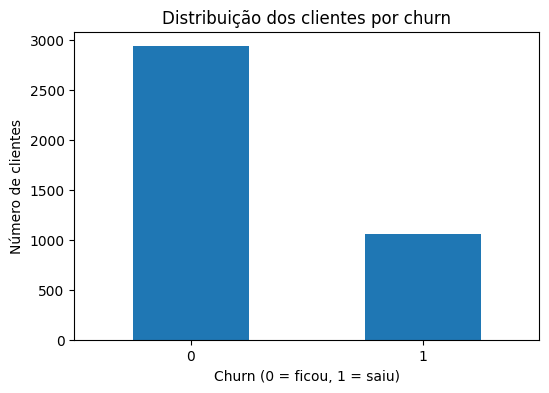

0    73.47
1    26.52
Name: Churn, dtype: float64


In [6]:
# Overall churn distribution

churn_counts = df['Churn'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
churn_counts.plot(kind='bar')
plt.title('Customer distribution by churn status')
plt.xlabel('Churn (0 = stayed, 1 = churned)')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.show()

print(df['Churn'].value_counts(normalize=True).mul(100).round(2))


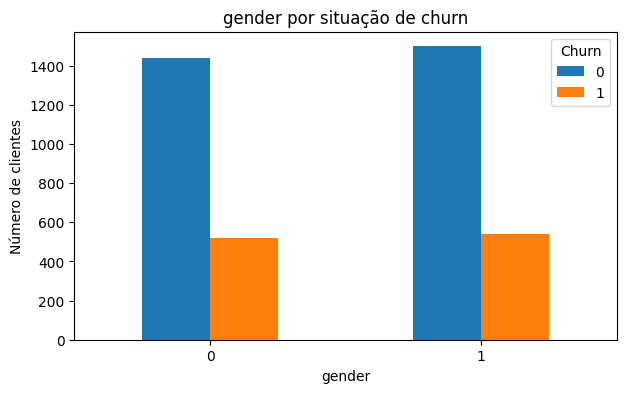

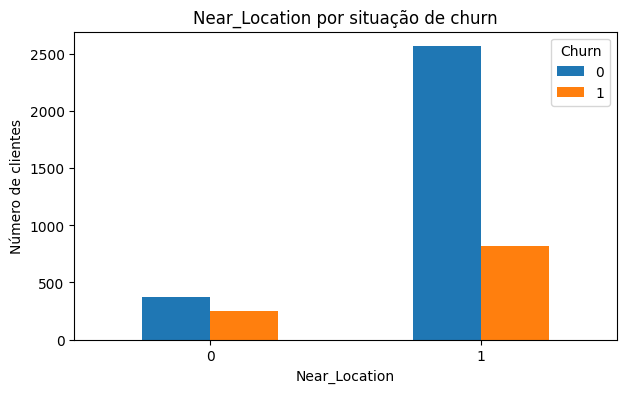

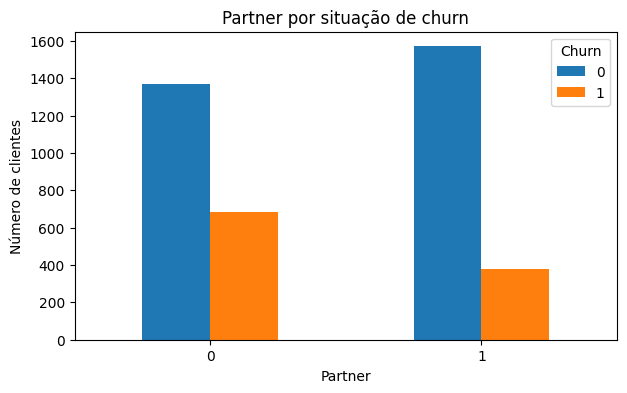

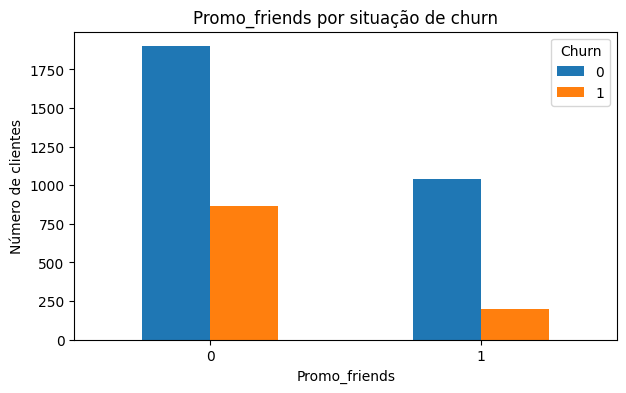

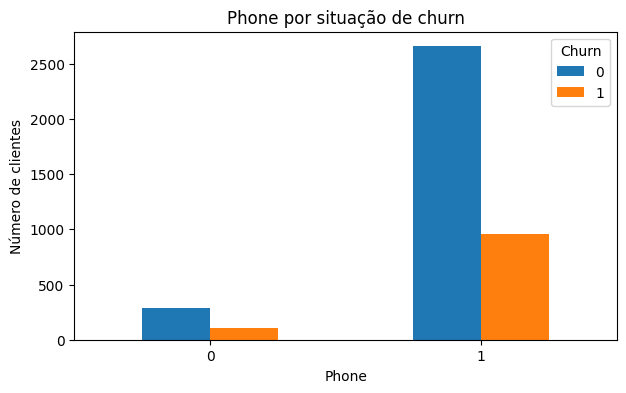

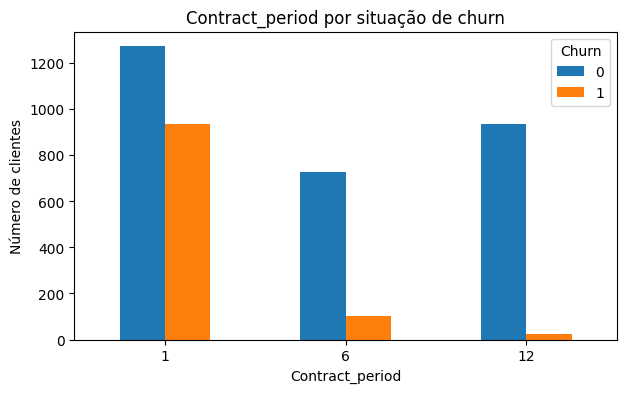

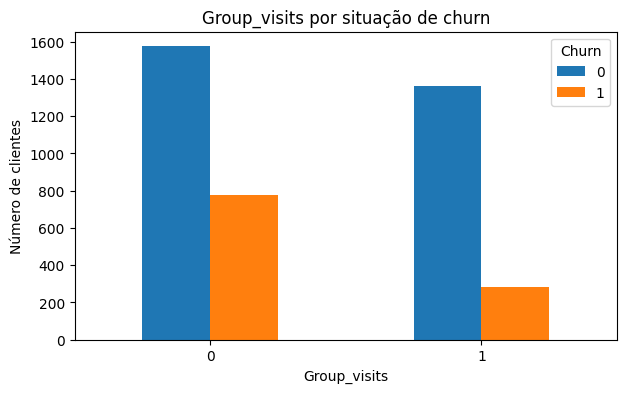

In [7]:
# Categorical / discrete features

categorical_features = [
    'gender',
    'Near_Location',
    'Partner',
    'Promo_friends',
    'Phone',
    'Contract_period',
    'Group_visits'
]

for col in categorical_features:
    comparison = pd.crosstab(df[col], df['Churn'])

    comparison.plot(kind='bar', figsize=(7, 4))
    plt.title(f'{col} by churn status')
    plt.xlabel(col)
    plt.ylabel('Number of customers')
    plt.xticks(rotation=0)
    plt.legend(title='Churn')
    plt.show()


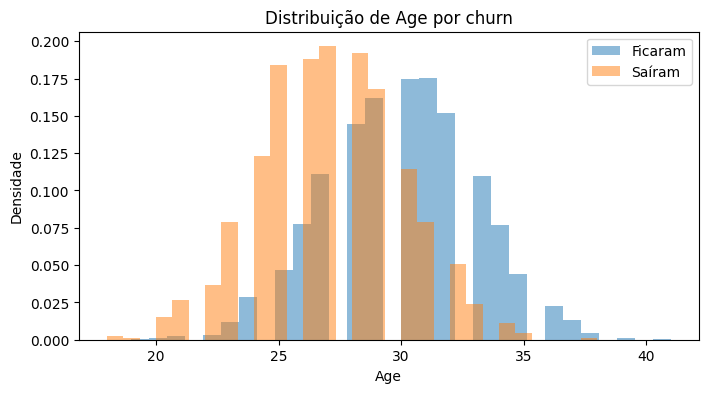

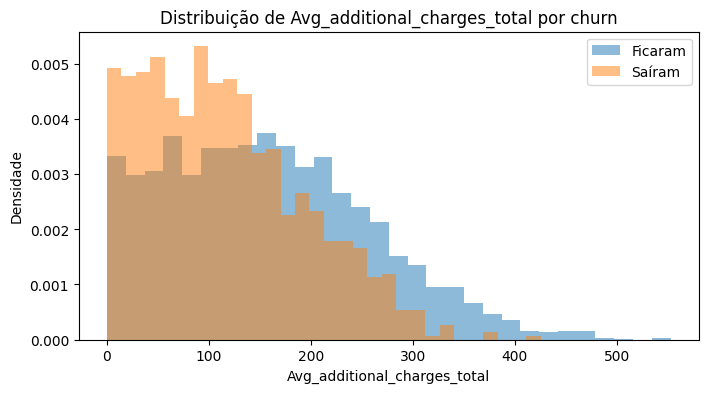

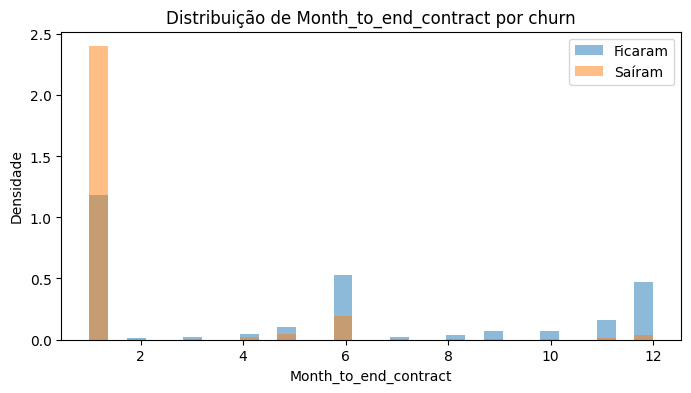

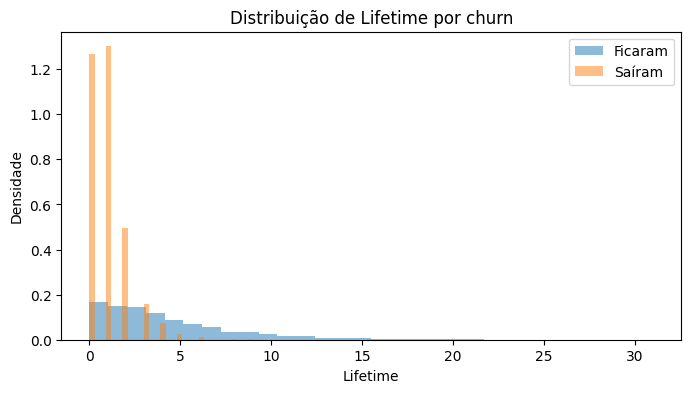

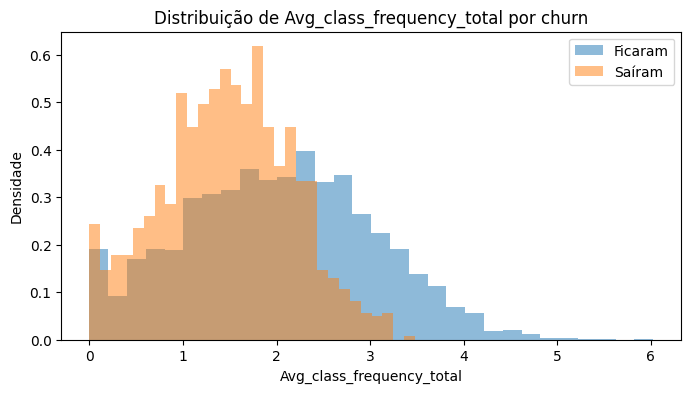

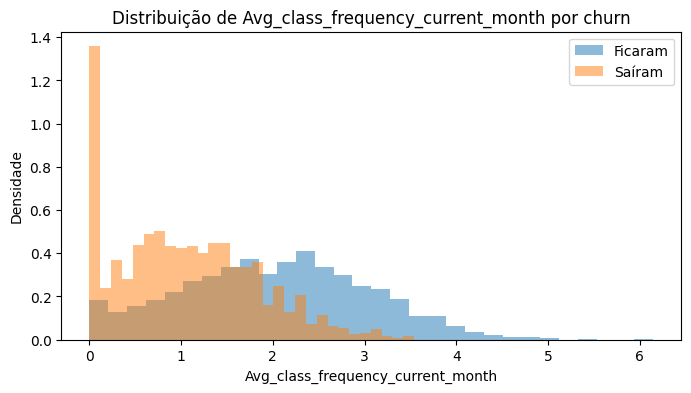

In [8]:
# Numeric features

numeric_features = [
    'Age',
    'Avg_additional_charges_total',
    'Month_to_end_contract',
    'Lifetime',
    'Avg_class_frequency_total',
    'Avg_class_frequency_current_month'
]

for col in numeric_features:
    plt.figure(figsize=(8, 4))

    df.loc[df['Churn'] == 0, col].plot(
        kind='hist',
        bins=30,
        alpha=0.5,
        density=True,
        label='Stayed'
    )

    df.loc[df['Churn'] == 1, col].plot(
        kind='hist',
        bins=30,
        alpha=0.5,
        density=True,
        label='Churned'
    )

    plt.title(f'Distribution of {col} by churn status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.show()


### Distribution Insights

The distributions reinforce the differences observed in the group averages.

Customers with shorter relationships, shorter contracts, and lower current-month attendance are more concentrated among those who churned.

The difference between historical attendance and current-month attendance is especially interesting: a recent decline in frequency may act as an early warning signal for churn.


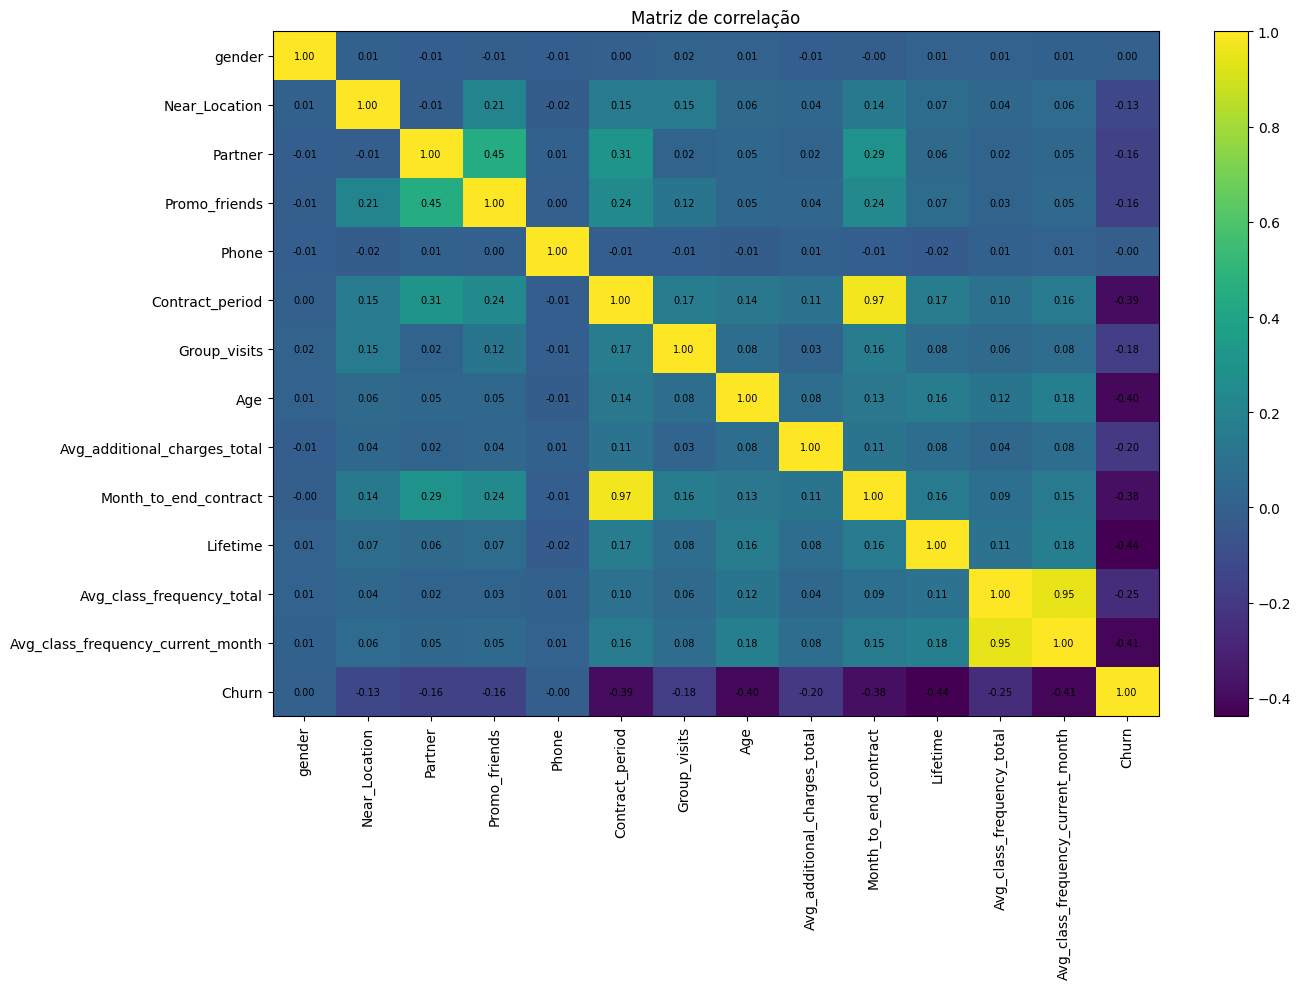

In [9]:
# Correlation matrix

corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
image = ax.imshow(corr_matrix, aspect='auto')

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f'{corr_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center',
            fontsize=7
        )

fig.colorbar(image, ax=ax)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()


In [10]:
# Correlações das características com churn
corr_matrix['Churn'].sort_values()


Lifetime                            -0.438220
Avg_class_frequency_current_month   -0.412348
Age                                 -0.404735
Contract_period                     -0.389984
Month_to_end_contract               -0.381393
Avg_class_frequency_total           -0.249715
Avg_additional_charges_total        -0.198697
Group_visits                        -0.175325
Promo_friends                       -0.162233
Partner                             -0.157986
Near_Location                       -0.128098
Phone                               -0.001177
gender                               0.000708
Churn                                1.000000
Name: Churn, dtype: float64

### Correlation Insights

The strongest negative correlations with churn are:

- `Lifetime`;
- `Avg_class_frequency_current_month`;
- `Age`;
- `Contract_period`;
- `Month_to_end_contract`.

Because these correlations are negative, higher values tend to be associated with lower churn.

There are also strong correlations between some explanatory variables, especially:

- `Contract_period` and `Month_to_end_contract`;
- `Avg_class_frequency_total` and `Avg_class_frequency_current_month`.

These relationships are expected because the variables describe closely related aspects of customer behaviour.

`gender` and `Phone` have almost no correlation with churn.


## 3. Predicting Customer Churn

I compare two binary classification models:

1. **Logistic Regression**
2. **Random Forest**

The target variable is `Churn`.

I use 80% of the data for training and 20% for validation, preserving the original churn proportion with stratification.


In [11]:
# Separate features and target

X = df.drop(columns='Churn')
y = df['Churn']

# Train / validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print('Training set:', X_train.shape)
print('Validation set:', X_valid.shape)

print('\nTraining churn rate:')
print(y_train.value_counts(normalize=True).round(3))

print('\nValidation churn rate:')
print(y_valid.value_counts(normalize=True).round(3))


Training set: (3200, 13)
Validation set: (800, 13)

Training churn rate:
0    0.735
1    0.265
Name: Churn, dtype: float64

Validation churn rate:
0    0.735
1    0.265
Name: Churn, dtype: float64


In [12]:
# Standardisation for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Logistic Regression
log_model = LogisticRegression(random_state=0, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_predictions = log_model.predict(X_valid_scaled)


In [13]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=0
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_valid)


In [14]:
# Model evaluation function

def model_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred)
    }

results = pd.DataFrame({
    'Logistic Regression': model_metrics(y_valid, log_predictions),
    'Random Forest': model_metrics(y_valid, rf_predictions)
})

results.round(4)


,Regressão Logística,Floresta Aleatória
Acurácia,0.9350,0.9225
Precisão,0.8960,0.8750
Recall,0.8538,0.8255


### Individual Churn Probability

Beyond predicting a binary outcome, Logistic Regression provides an estimated probability that each customer will churn.

This makes the model more useful from a business perspective because customers can be ranked by risk and prioritised for retention actions.


In [15]:
# Predicted churn probability from Logistic Regression

churn_probability = log_model.predict_proba(X_valid_scaled)[:, 1]

probabilities = pd.DataFrame({
    'actual_churn': y_valid.values,
    'churn_probability': churn_probability
})

probabilities.head(10)


,churn_real,churn_probability
0,1,0.908755
1,0,0.035807
2,0,0.006239
3,0,0.021839
4,0,0.011071
5,0,0.001392
6,0,0.000023
7,0,0.059280
8,1,0.997251
9,0,0.008123


### Simple Risk Segmentation

To make the probabilities easier to use operationally, I divide customers into three illustrative risk groups:

- **Low risk:** probability below 30%
- **Medium risk:** probability between 30% and 60%
- **High risk:** probability above 60%

These thresholds are not presented as fixed business rules. In a real company, they should be calibrated according to campaign capacity, retention cost, and business priorities.


In [16]:
# Create illustrative risk bands

def risk_group(prob):
    if prob < 0.30:
        return 'Low risk'
    elif prob < 0.60:
        return 'Medium risk'
    else:
        return 'High risk'

probabilities['risk_group'] = probabilities['churn_probability'].apply(risk_group)

probabilities.head(10)


,churn_real,churn_probability,risk_group
0,1,0.908755,Alto risco
1,0,0.035807,Baixo risco
2,0,0.006239,Baixo risco
3,0,0.021839,Baixo risco
4,0,0.011071,Baixo risco
5,0,0.001392,Baixo risco
6,0,0.000023,Baixo risco
7,0,0.059280,Baixo risco
8,1,0.997251,Alto risco
9,0,0.008123,Baixo risco


In [17]:
# Validation customers by risk group

risk_summary = probabilities['risk_group'].value_counts()
risk_summary


Baixo risco    556
Alto risco     188
Risco médio     56
Name: risk_group, dtype: int64

### Model Comparison

On the validation set, Logistic Regression performed better across all three evaluation metrics.

**Logistic Regression**

- Accuracy: **0.935**
- Precision: **0.896**
- Recall: **0.854**

**Random Forest**

- Accuracy: **0.923**
- Precision: **0.875**
- Recall: **0.826**

For this dataset, I would use Logistic Regression as the primary churn model.

In addition to strong classification performance, it also provides individual churn probabilities that can be translated into actionable risk levels.


In [18]:
# Random Forest feature importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


Lifetime                             0.270336
Avg_class_frequency_current_month    0.176142
Avg_class_frequency_total            0.135955
Age                                  0.121477
Avg_additional_charges_total         0.088327
Month_to_end_contract                0.072941
Contract_period                      0.067406
Group_visits                         0.016090
gender                               0.012293
Partner                              0.012099
Promo_friends                        0.010499
Near_Location                        0.009924
Phone                                0.006511
dtype: float64

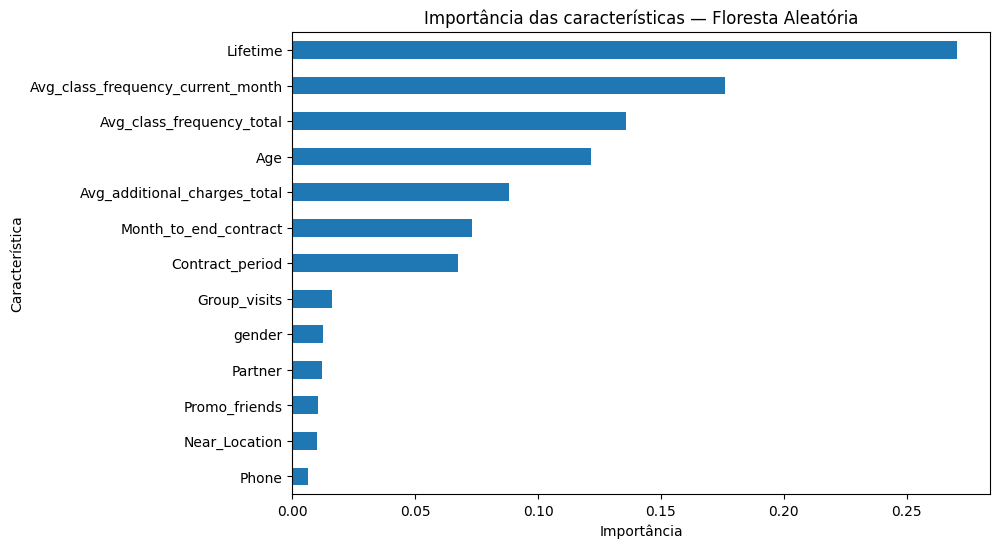

In [19]:
# Visualise feature importance

plt.figure(figsize=(9, 6))
feature_importance.sort_values().plot(kind='barh')
plt.title('Feature importance — Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


### Most Important Churn Factors

Random Forest feature importance supports the exploratory findings.

The most influential features include:

- customer lifetime;
- current-month gym frequency;
- historical gym frequency;
- age;
- additional-service spending;
- contract duration and remaining contract time.

Recent engagement and the strength of the customer's relationship with the gym appear especially important for retention.


## 4. Customer Segmentation

Prediction answers **who may churn**.

Clustering adds a different perspective: **what types of customers exist, and how do their retention patterns differ?**

I remove the `Churn` target from the clustering features, standardise the variables, review a hierarchical clustering dendrogram, and then use K-means to create five customer segments.


In [20]:
# Remove churn before clustering

X_cluster = df.drop(columns='Churn')

# Standardise clustering features
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)


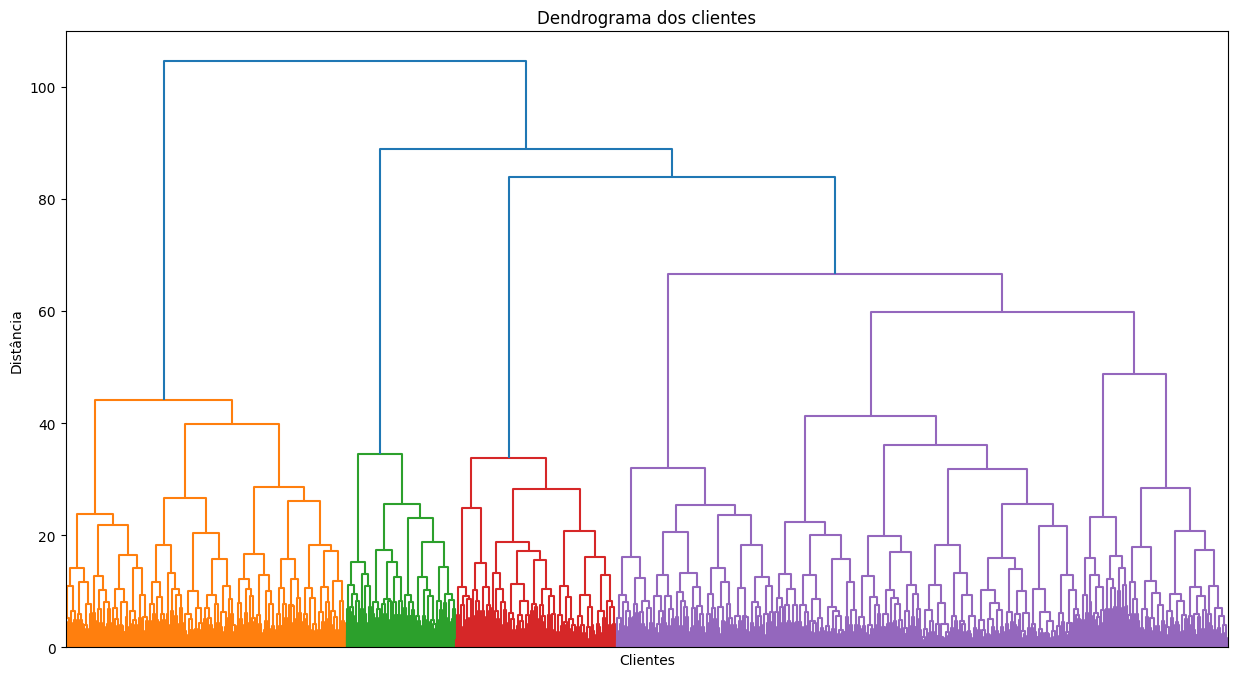

In [21]:
# Hierarchical linkage matrix

linked = linkage(X_cluster_scaled, method='ward')

# Dendrogram
plt.figure(figsize=(15, 8))
dendrogram(
    linked,
    orientation='top',
    no_labels=True
)
plt.title('Customer dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()


### Clustering Approach

The dendrogram indicates that customers can be separated into groups with distinct behavioural patterns.

For the final segmentation, I use **5 K-means clusters** so that churn behaviour and customer characteristics can be compared across a manageable number of profiles.


In [22]:
# K-means with 5 clusters

kmeans = KMeans(
    n_clusters=5,
    random_state=0,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster_scaled)

df_clustered = df.copy()
df_clustered['cluster'] = clusters

df_clustered.head()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn,cluster
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0,1
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0,3
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0,3


In [23]:
# Quantidade de clientes em cada cluster
df_clustered['cluster'].value_counts().sort_index()


0    1010
1     385
2     505
3    1262
4     838
Name: cluster, dtype: int64

In [24]:
# Médias das características por cluster
cluster_means = df_clustered.groupby('cluster').mean()

cluster_means.round(3)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster,,,,,,,,,,,,,,
0,0.503,0.959,0.783,0.574,1.000,10.889,0.543,29.982,160.761,9.954,4.737,1.982,1.975,0.028
1,0.522,0.862,0.470,0.306,0.000,4.787,0.426,29.301,143.958,4.475,3.925,1.847,1.716,0.268
2,0.495,0.000,0.463,0.079,1.000,2.352,0.216,28.477,135.458,2.198,2.810,1.660,1.477,0.444
3,0.486,1.000,0.350,0.240,1.000,1.948,0.342,28.168,131.622,1.857,2.441,1.248,1.013,0.514
4,0.560,0.976,0.357,0.230,0.999,2.669,0.474,30.125,161.658,2.459,4.899,2.852,2.850,0.068


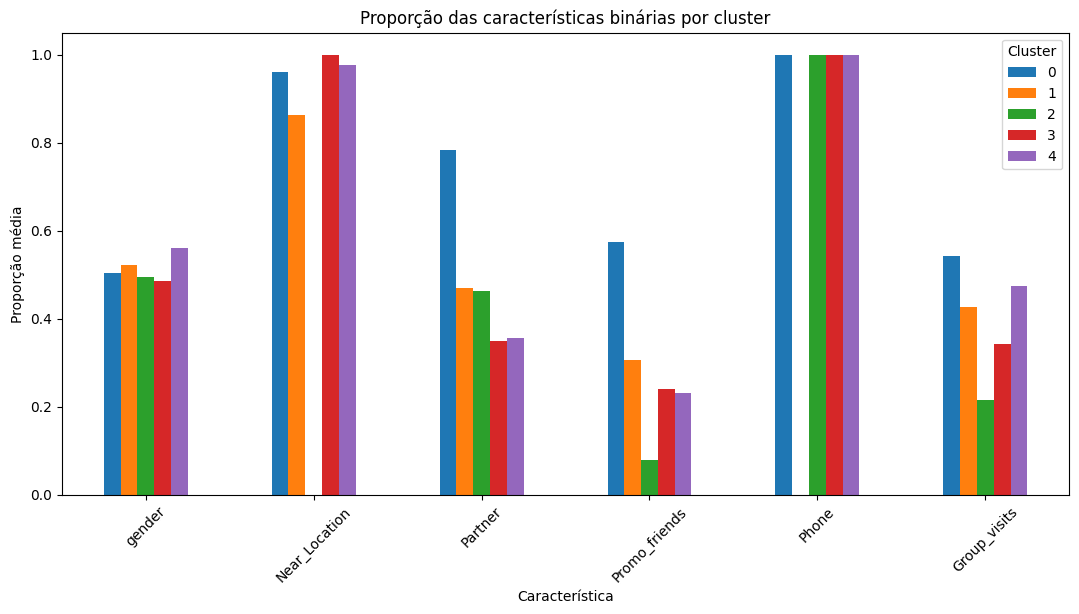

In [25]:
# Average binary-feature values by cluster

binary_features = [
    'gender',
    'Near_Location',
    'Partner',
    'Promo_friends',
    'Phone',
    'Group_visits'
]

df_clustered.groupby('cluster')[binary_features].mean().T.plot(
    kind='bar',
    figsize=(13, 6)
)

plt.title('Average binary-feature proportions by cluster')
plt.xlabel('Feature')
plt.ylabel('Average proportion')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.show()


<Figure size 900x400 with 0 Axes>

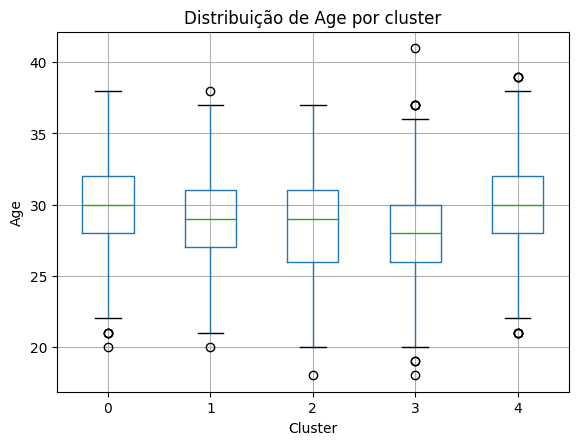

<Figure size 900x400 with 0 Axes>

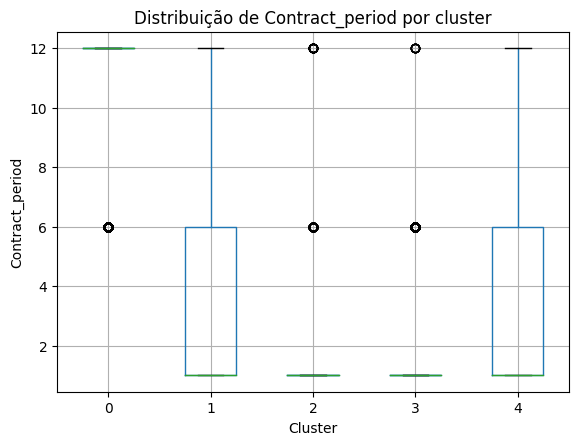

<Figure size 900x400 with 0 Axes>

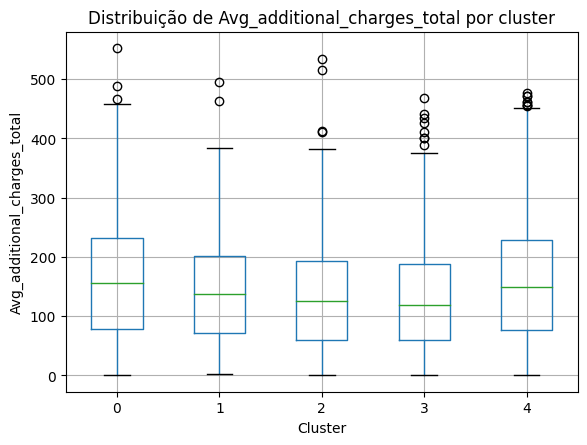

<Figure size 900x400 with 0 Axes>

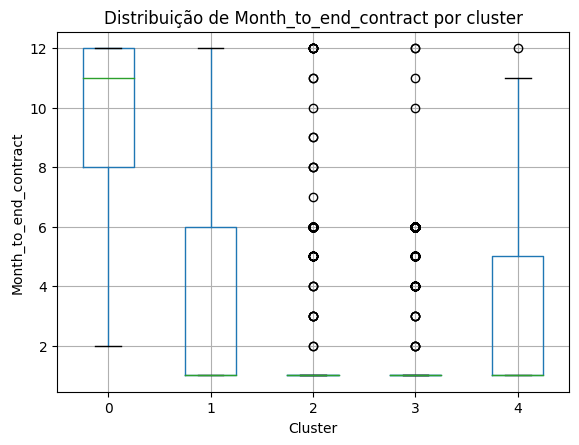

<Figure size 900x400 with 0 Axes>

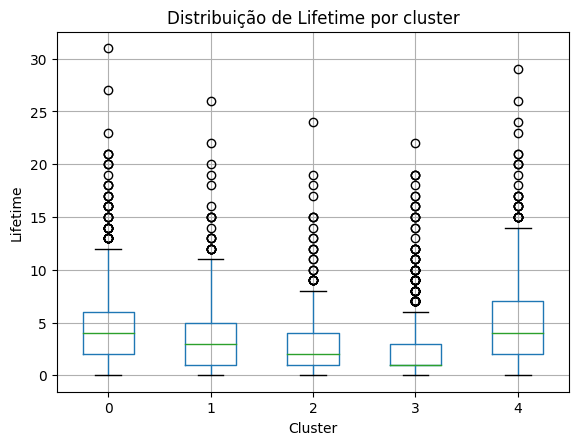

<Figure size 900x400 with 0 Axes>

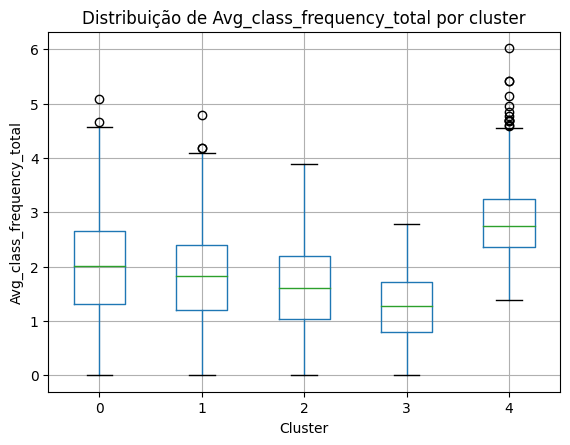

<Figure size 900x400 with 0 Axes>

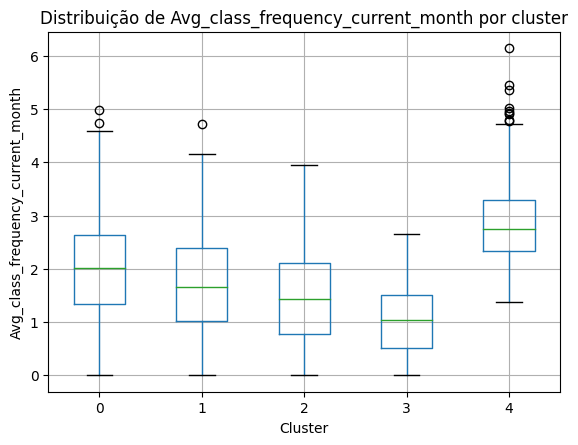

In [26]:
# Numeric-feature distributions by cluster

cluster_numeric_features = [
    'Age',
    'Contract_period',
    'Avg_additional_charges_total',
    'Month_to_end_contract',
    'Lifetime',
    'Avg_class_frequency_total',
    'Avg_class_frequency_current_month'
]

for col in cluster_numeric_features:
    plt.figure(figsize=(9, 4))
    df_clustered.boxplot(column=col, by='cluster')
    plt.title(f'Distribution of {col} by cluster')
    plt.suptitle('')
    plt.xlabel('Cluster')
    plt.ylabel(col)
    plt.show()


In [27]:
# Churn rate by cluster

cluster_churn = (
    df_clustered
    .groupby('cluster')['Churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
)

cluster_churn['churn_rate_percent'] = (
    cluster_churn['churn_rate'] * 100
).round(2)

cluster_churn


,churn_rate,clientes,churn_rate_percent
cluster,,,
0,0.027723,1010,2.77
1,0.267532,385,26.75
2,0.443564,505,44.36
3,0.514263,1262,51.43
4,0.068019,838,6.80


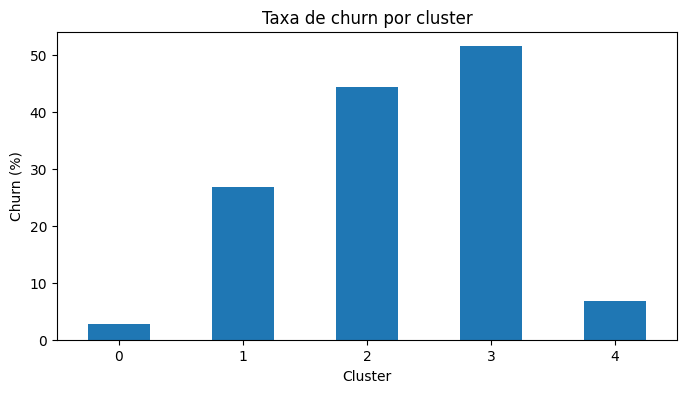

In [28]:
# Visualise churn rate by cluster

plt.figure(figsize=(8, 4))
(
    df_clustered
    .groupby('cluster')['Churn']
    .mean()
    .mul(100)
    .plot(kind='bar')
)

plt.title('Churn rate by cluster')
plt.xlabel('Cluster')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()


### Customer Segment Profiles

The executed clustering results show clear differences in churn rates:

- **Cluster 3 — Highest risk:** **51.43% churn**. This is the largest cluster, with relatively short contracts, short customer lifetime, and the lowest current-month attendance among the major groups.
- **Cluster 2 — High risk:** **44.36% churn**. These customers are distinguished by not living or working close to the gym and by relatively short contracts and lower attendance.
- **Cluster 1 — Medium risk:** **26.75% churn**. This group sits close to the overall churn average and has mid-range contract length and activity.
- **Cluster 4 — Low risk:** **6.80% churn**. Customers show high visit frequency, longer lifetime, and relatively high additional spending.
- **Cluster 0 — Most loyal:** **2.77% churn**. These customers have the longest contracts, many months remaining, strong partner-programme participation, and high engagement.

The segmentation reinforces the main analytical pattern: **longer relationships, stronger attendance, and longer contracts are associated with more stable customer groups.**


## 5. Conclusions and Retention Recommendations

The analysis shows that customer churn at Model Fitness is strongly connected to **engagement** and **contract commitment**.

The overall churn rate is approximately **26.5%**.

Customers who leave tend to:

- have shorter customer lifetimes;
- hold shorter contracts;
- have fewer months remaining on their contract;
- visit the gym less frequently;
- show particularly low attendance in the current month.

Logistic Regression provided the strongest model performance, with approximately **93.5% accuracy**, **89.6% precision**, and **85.4% recall**.

The clustering analysis adds an important business layer. **Clusters 3 and 2 are the highest-risk segments**, while **Clusters 0 and 4 are considerably more stable**.

### Recommended Retention Actions

1. **Create early-warning alerts for declining attendance.**  
   A meaningful drop in current-month frequency could trigger proactive contact, personalised class suggestions, or an incentive to return.

2. **Strengthen onboarding during the first months.**  
   Customers with a short lifetime have higher churn risk. A structured onboarding programme during the first 1–3 months could help customers build habits and feel more connected to the gym.

3. **Encourage longer contracts and early renewals.**  
   Short contracts are strongly associated with churn. Longer-term plans, progressive benefits, and renewal campaigns before expiry could improve retention.

4. **Increase social engagement.**  
   Group classes, partner programmes, and referral initiatives are more common among stable customers. Social and community-based activities may help strengthen customer commitment.

5. **Use churn probabilities to prioritise retention efforts.**  
   Instead of treating every customer the same, the gym can focus retention resources on customers with the highest predicted risk.

6. **Combine prediction and segmentation.**  
   Individual churn probability identifies who may leave, while clustering provides context about the type of customer. Used together, they can support more personalised retention strategies.

## What I Learned

What I found most valuable in this project was seeing how predictive modelling becomes much more useful when it is connected to an operational decision.

A churn probability by itself is only a number. Turning that probability into risk groups, understanding the behaviours behind it, and combining it with customer segments makes the analysis much more actionable.

This project strengthened my understanding of how exploratory analysis, machine learning, and business judgement can work together to support customer-retention decisions.
